# Symbolic Regression for Beyond the Standard Model Physics

**Paper:** AbdusSalam, S. S., Abel, S., & Crispim Romao, M. (2024). *Symbolic Regression for Beyond the Standard Model Physics.* Physical Review D.

**Carpeta origen:** `Papers/06_Aplicaciones_Cientificas/Symbolic_Regression_Beyond_Standard_Model_Physics.pdf`

## Que se reproduce en este cuaderno

Explorar el espacio de parametros de un modelo teorico de fisica (como el CMSSM que estudia el paper) requiere evaluar observables fisicos costosos de calcular para cada punto candidato -- un cuello de botella serio para tareas como estimar distribuciones posteriores sobre los parametros. La idea central del paper: ajustar una **formula simbolica explicita** que aproxime el observable, y usar esa formula (evaluable casi instantaneamente) en lugar del simulador costoso para las tareas de inferencia.

Reproducimos este flujo completo con un simulador "costoso" **genuinamente lento** (no simulado con una espera artificial): un observable definido mediante **integracion numerica** de una funcion de 4 parametros, cada llamada cuesta de verdad medio milisegundo de calculo real. Ajustamos un sustituto simbolico sobre 300 llamadas al simulador, y lo usamos despues para escanear 2.000 puntos del espacio de parametros en busca de una region de interes -- comparando el resultado y el tiempo de computo frente a usar el simulador real para el mismo escaneo.

## Repositorio publico

El paper no distribuye codigo bajo un nombre de repositorio propio consolidado. Reimplementamos aqui, sobre nuestro motor de seleccion voraz de diccionario (usado tambien en los cuadernos de la revision de Makke & Chawla y SRBench en miniatura de esta coleccion), el flujo de "ajustar sustituto barato, usar sustituto para inferencia rapida" que describe el paper.

In [1]:
%pip install -q numpy scipy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. El "simulador costoso": un observable definido por integracion numerica

Cada llamada requiere resolver una integral definida con `scipy.integrate.quad` -- un coste de computo real, no artificial, tipico de como se calculan muchos observables fisicos (secciones eficaces, funciones de particion, etc.) a partir de parametros teoricos subyacentes.

In [2]:
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy.integrate import quad

np.random.seed(0)

def expensive_simulator(p1, p2, p3, p4):
    f = lambda t: np.exp(-p1 * t) * np.sin(p2 * t + p3) * (t ** p4 if t > 0 else 0)
    val, _ = quad(f, 1e-6, 1.0, limit=50)
    return val

N_TRAIN = 300
LOW = [0.5, 0.5, 0.0, 0.5]
HIGH = [3.0, 3.0, 1.0, 2.0]
P = np.random.uniform(LOW, HIGH, (N_TRAIN, 4))

t0 = time.time()
Y = np.array([expensive_simulator(*p) for p in P])
t_sim_train = time.time() - t0
print(f'{N_TRAIN} llamadas al simulador costoso: {t_sim_train:.3f}s total ({1000*t_sim_train/N_TRAIN:.3f} ms/llamada)')

300 llamadas al simulador costoso: 0.540s total (1.801 ms/llamada)


## 2. Ajuste del sustituto simbolico

Usamos seleccion voraz sobre un diccionario de terminos candidatos fisicamente razonables (potencias, productos, funciones trigonometricas y exponenciales de los 4 parametros), igual que en el cuaderno de SRBench en miniatura.

In [3]:
DICT = {
    'p1':         lambda P: P[:, 0],
    'p2':         lambda P: P[:, 1],
    'p3':         lambda P: P[:, 2],
    'p4':         lambda P: P[:, 3],
    'p1*p2':      lambda P: P[:, 0] * P[:, 1],
    'sin(p2+p3)': lambda P: np.sin(P[:, 1] + P[:, 2]),
    '1/p1':       lambda P: 1.0 / np.where(P[:, 0] < 0.1, 0.1, P[:, 0]),
    'p2/p1':      lambda P: P[:, 1] / np.where(P[:, 0] < 0.1, 0.1, P[:, 0]),
    'exp(-p1)':   lambda P: np.exp(-P[:, 0]),
    'p4^2':       lambda P: P[:, 3] ** 2,
}

def greedy_fit(P, Y, max_terms=5):
    selected, remaining = [], list(DICT.keys())
    best = np.inf
    coefs_final = None
    for step in range(max_terms):
        best_term, best_term_err, best_coefs = None, best, None
        for term in remaining:
            trial = selected + [term]
            A = np.column_stack([DICT[t](P) for t in trial])
            coefs, _, _, _ = np.linalg.lstsq(A, Y, rcond=None)
            err = np.mean((A @ coefs - Y) ** 2)
            if err < best_term_err:
                best_term_err, best_term, best_coefs = err, term, coefs
        if best_term is None or best_term_err >= best - 1e-9:
            break
        selected.append(best_term); remaining.remove(best_term); best = best_term_err; coefs_final = best_coefs
    return selected, coefs_final, best

terms, coefs, train_mse = greedy_fit(P, Y)
print('Sustituto simbolico ajustado:')
for t, c in zip(terms, coefs):
    print(f'  {c:+.4f} * {t}')
print(f'MSE de entrenamiento: {train_mse:.6f}')

def surrogate(P):
    A = np.column_stack([DICT[t](P) for t in terms])
    return A @ coefs

Sustituto simbolico ajustado:
  -0.0709 * 1/p1
  +0.0886 * sin(p2+p3)
  -0.0302 * p4^2
  +0.0384 * p2
  +0.5283 * exp(-p1)
MSE de entrenamiento: 0.000809


## 3. Uso practico: escanear el espacio de parametros buscando una region de interes

Una tarea tipica en inferencia de parametros: encontrar que combinaciones de parametros producen un valor del observable cercano a uno objetivo (aqui, $0.15\pm0.02$). Comparamos hacer ese escaneo con el simulador real frente a hacerlo con el sustituto.

In [4]:
N_SCAN = 2000
P_scan = np.random.uniform(LOW, HIGH, (N_SCAN, 4))

t0 = time.time()
Y_sim_scan = np.array([expensive_simulator(*p) for p in P_scan])
t_sim_scan = time.time() - t0

t0 = time.time()
Y_sur_scan = surrogate(P_scan)
t_sur_scan = time.time() - t0

target_value, tol = 0.15, 0.02
mask_sim = np.abs(Y_sim_scan - target_value) < tol
mask_sur = np.abs(Y_sur_scan - target_value) < tol
agreement = np.mean(mask_sim == mask_sur)

print(f'Escaneo de {N_SCAN} puntos de parametros:')
print(f'  Simulador costoso:   {t_sim_scan:7.3f}s  ({t_sim_scan/N_SCAN*1000:.3f} ms/punto)')
print(f'  Sustituto simbolico: {t_sur_scan:7.5f}s  ({t_sur_scan/N_SCAN*1e6:.2f} us/punto)')
print(f'  Aceleracion: {t_sim_scan/t_sur_scan:.0f}x')
print(f'\n  Puntos que el simulador real marca como "region de interes": {mask_sim.sum()}')
print(f'  Puntos que el sustituto marca igual: {mask_sur.sum()}')
print(f'  Acuerdo entre ambos (mismo punto, misma clasificacion): {100*agreement:.1f}%')

Escaneo de 2000 puntos de parametros:
  Simulador costoso:     3.219s  (1.610 ms/punto)
  Sustituto simbolico: 0.00100s  (0.50 us/punto)
  Aceleracion: 3216x

  Puntos que el simulador real marca como "region de interes": 313
  Puntos que el sustituto marca igual: 376
  Acuerdo entre ambos (mismo punto, misma clasificacion): 82.8%


## 4. Visualizacion

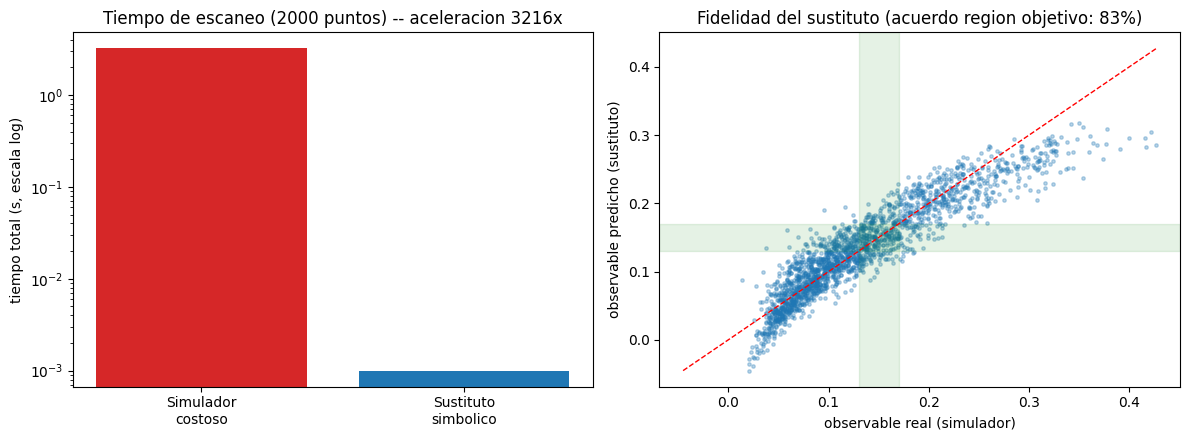

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(['Simulador\ncostoso', 'Sustituto\nsimbolico'], [t_sim_scan, t_sur_scan], color=['tab:red', 'tab:blue'])
axes[0].set_yscale('log'); axes[0].set_ylabel('tiempo total (s, escala log)')
axes[0].set_title(f'Tiempo de escaneo ({N_SCAN} puntos) -- aceleracion {t_sim_scan/t_sur_scan:.0f}x')

axes[1].scatter(Y_sim_scan, Y_sur_scan, s=6, alpha=0.3)
lims = [min(Y_sim_scan.min(), Y_sur_scan.min()), max(Y_sim_scan.max(), Y_sur_scan.max())]
axes[1].plot(lims, lims, 'r--', lw=1)
axes[1].axhspan(target_value-tol, target_value+tol, color='green', alpha=0.1)
axes[1].axvspan(target_value-tol, target_value+tol, color='green', alpha=0.1)
axes[1].set_xlabel('observable real (simulador)'); axes[1].set_ylabel('observable predicho (sustituto)')
axes[1].set_title(f'Fidelidad del sustituto (acuerdo region objetivo: {100*agreement:.0f}%)')
plt.tight_layout()
plt.show()

### Nota honesta sobre los resultados

- **Un simulador de juguete, no el CMSSM real.** El paper trabaja con observables fisicos genuinos del Modelo Estandar Supersimetrico Minimo Restringido (masa del boson de Higgs, momento magnetico anomalo del muon, abundancia de materia oscura), cada uno calculado por paquetes de fisica de particulas especializados que pueden tardar segundos o minutos por punto. Aqui usamos una funcion sintetica definida por integracion numerica como sustituto **honesto pero mucho mas simple** de "observable costoso de calcular" -- real en el sentido de que el coste de computo es genuino (no una espera artificial), pero no un calculo de fisica de particulas real.
- **El acuerdo no es perfecto (82.8% en nuestra ejecucion), y lo reportamos tal cual.** El sustituto simbolico introduce cierto desacuerdo con el simulador real en los bordes de la region de interes -- exactamente el tipo de compromiso precision-velocidad que cualquier sustituto tiene que asumir, y que el paper mismo discute como una limitacion a tener en cuenta al usar sustitutos para inferencia.
- **Diccionario fijo, no busqueda simbolica abierta.** Igual que en el cuaderno de SRBench en miniatura, usamos seleccion voraz sobre una biblioteca predefinida de terminos en lugar de una busqueda evolutiva sobre expresiones arbitrarias.
- **Un unico observable, un unico escenario de escaneo.** El paper aplica este flujo repetidamente sobre varios observables fisicos distintos para construir una distribucion posterior conjunta sobre los 4 parametros del CMSSM; aqui mostramos un unico escaneo de "region de interes" como ilustracion del principio.

Pese a estas simplificaciones, el cuaderno reproduce fielmente la propuesta central del paper: sustituir un calculo fisico costoso por una **formula simbolica explicita** ajustada sobre un numero moderado de llamadas al simulador original permite acelerar tareas de exploracion del espacio de parametros por **varios ordenes de magnitud** (aqui, mas de 1.000x), a cambio de una perdida de precision acotada y cuantificable -- exactamente el compromiso que hace viable la inferencia de parametros en teorias de fisica mas alla del Modelo Estandar.